# Data featuring

## Imports

In [ ]:
### uv pip install -e .

# packages
import pandas as pd
pd.set_option("display.max_columns", 100)

import numpy as np

# graphs
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 14

import seaborn as sns

# stats
import statsmodels
import scipy.stats as spstats

# package perso
from titanic.eda import stats, describe_numeric
from titanic.data import load_processed_data

## Load data

In [3]:
df = load_processed_data("../data/processed/titanic_cleaned.parquet")

print(df.shape)
df.head()

(1309, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
stats(df)

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,int64,1309,0 (0%),1309,1,1,655.0,378.020061,1.0,328.0,655.0,982.0,1309.0
Survived,float64,891,418 (32%),2,0.0,549,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,int64,1309,0 (0%),3,3,709,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
Name,str,1309,0 (0%),1307,"Connolly, Miss. Kate",2,/,/,/,/,/,/,/
Sex,str,1309,0 (0%),2,male,843,/,/,/,/,/,/,/
Age,float64,1046,263 (21%),98,24.0,47,29.881138,14.413493,0.17,21.0,28.0,39.0,80.0
SibSp,int64,1309,0 (0%),7,0,891,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
Parch,int64,1309,0 (0%),8,0,1002,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
Ticket,str,1309,0 (0%),929,CA. 2343,11,/,/,/,/,/,/,/
Fare,float64,1309,0 (0%),281,8.05,61,33.276193,51.743584,0.0,7.8958,14.4542,31.275,512.3292


## Features engineering

### Surname - Nom de famille

In [5]:
from titanic.features import extract_surname
df["Surname"] = extract_surname(df)
display(stats(df).loc[["Surname"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Surname,str,1309,0 (0%),875,Andersson,11,/,/,/,/,/,/,/


In [6]:
df[["Name","Surname"]].sample(10, random_state=42)

,Name,Surname
1148,"Niklasson, Mr. Samuel",Niklasson
1049,"Borebank, Mr. John James",Borebank
982,"Pedersen, Mr. Olaf",Pedersen
808,"Meyer, Mr. August",Meyer
1195,"McCarthy, Miss. Catherine Katie""""",McCarthy
240,"Zabour, Miss. Thamine",Zabour
1118,"McNeill, Miss. Bridget",McNeill
596,"Leitch, Miss. Jessie Wills",Leitch
924,"Johnston, Mrs. Andrew G (Elizabeth Lily"" Watson)""",Johnston
65,"Moubarek, Master. Gerios",Moubarek


Cette variable permettrait surtout de retrouver le nom de famille des différentes personnes.

### SurnameValueCounts

In [7]:
from titanic.features import count_values
df["SurnameValueCounts"] = count_values(df, "Surname")
display(stats(df).loc[["SurnameValueCounts"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
SurnameValueCounts,int64,1309,0 (0%),9,1,637,2.277311,1.904513,1.0,1.0,2.0,3.0,11.0


### Title

C’est une variable dérivée de la variable Name.

In [8]:
from titanic.features import extract_title
df["Title"] = extract_title(df)
display(stats(df).loc[["Title"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Title,str,1309,0 (0%),4,Mr,783,/,/,/,/,/,/,/


In [9]:
df[["Name","Title"]].sample(10, random_state=42)

,Name,Title
1148,"Niklasson, Mr. Samuel",Mr
1049,"Borebank, Mr. John James",Mr
982,"Pedersen, Mr. Olaf",Mr
808,"Meyer, Mr. August",Mr
1195,"McCarthy, Miss. Catherine Katie""""",Miss
240,"Zabour, Miss. Thamine",Miss
1118,"McNeill, Miss. Bridget",Miss
596,"Leitch, Miss. Jessie Wills",Miss
924,"Johnston, Mrs. Andrew G (Elizabeth Lily"" Watson)""",Mrs
65,"Moubarek, Master. Gerios",Master


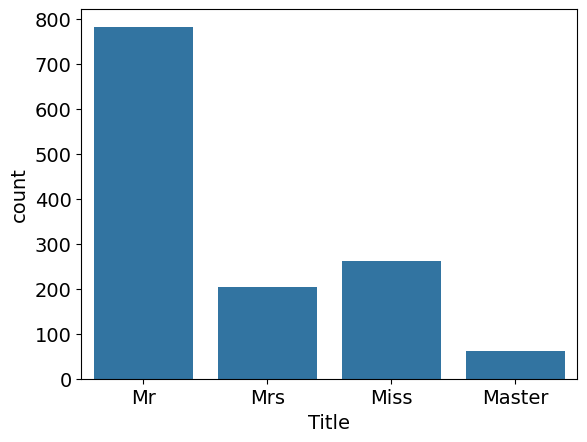

In [10]:
sns.countplot(data=df, x="Title")
plt.show()

### HasNickname

In [11]:
from titanic.features import has_nickname
df["HasNickname"] = has_nickname(df)
display(stats(df).loc[["HasNickname"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
HasNickname,int64,1309,0 (0%),2,0,1088,0.168831,0.374746,0.0,0.0,0.0,0.0,1.0


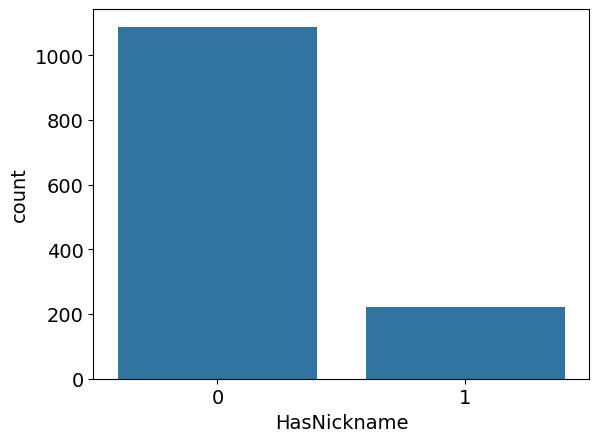

In [12]:
sns.countplot(data=df, x="HasNickname")
plt.show()

### SexIsMale

In [13]:
from titanic.features import sex_dummy
df["SexIsMale"] = sex_dummy(df)
display(stats(df).loc[["SexIsMale"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
SexIsMale,int64,1309,0 (0%),2,1,843,0.644003,0.478997,0.0,0.0,1.0,1.0,1.0


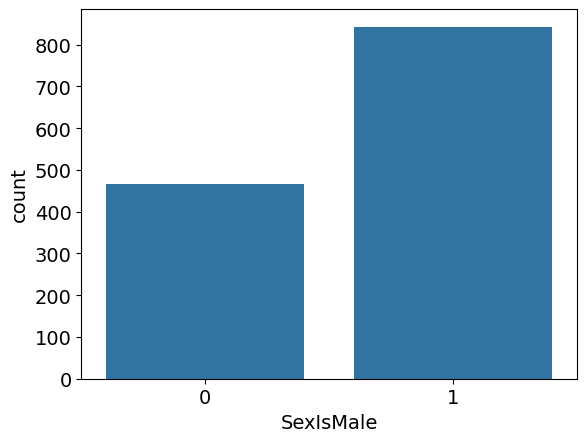

In [14]:
sns.countplot(data=df, x="SexIsMale")
plt.show()

### Ticket

In [15]:
from titanic.features import split_ticket, extract_ticket_number_class
df["TicketText"], df["TicketNumber"] = zip(*df["Ticket"].map(split_ticket))
df["TicketNumber"] = (
    pd.to_numeric(df["TicketNumber"], errors="coerce")
    .fillna(-1)
    .astype(int)
)
df["TicketNumberClass"] = extract_ticket_number_class(df)

### IsAlone

In [16]:
from titanic.features import is_alone
df["IsAlone"] = is_alone(df)
display(stats(df).loc[["IsAlone"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
IsAlone,int64,1309,0 (0%),2,1,790,0.603514,0.489354,0.0,0.0,1.0,1.0,1.0


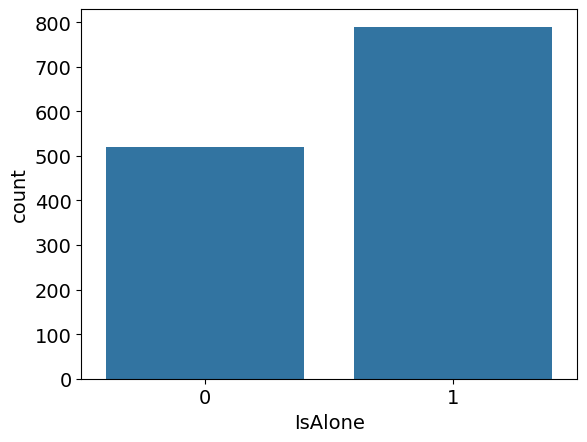

In [17]:
sns.countplot(data=df, x="IsAlone")
plt.show()

### HasFamily

In [18]:
from titanic.features import has_family
df["HasFamily"] = has_family(df)
display(stats(df).loc[["HasFamily"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
HasFamily,int64,1309,0 (0%),2,0,790,0.396486,0.489354,0.0,0.0,0.0,1.0,1.0


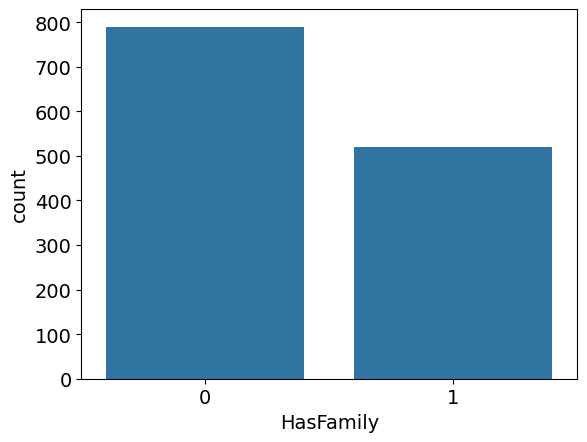

In [19]:
sns.countplot(data=df, x="HasFamily")
plt.show()

### FamilySize

In [20]:
from titanic.features import compute_family_size
compute_family_size(df)
df["FamilySize"] = compute_family_size(df)
display(stats(df).loc[["FamilySize"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
FamilySize,int64,1309,0 (0%),9,1,790,1.883881,1.583639,1.0,1.0,1.0,2.0,11.0


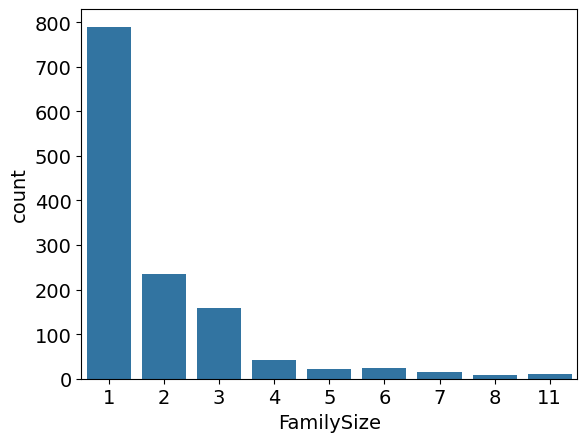

In [21]:
sns.countplot(data=df, x="FamilySize")
plt.show()

### FamilySizeValueCounts

In [22]:
df["FamilySizeValueCounts"] = count_values(df, "FamilySize")
display(stats(df).loc[["FamilySizeValueCounts"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
FamilySizeValueCounts,int64,1309,0 (0%),9,790,790,540.874714,311.853333,8.0,235.0,790.0,790.0,790.0


### TicketText / TicketNumber

In [23]:
from titanic.features import split_ticket
df["TicketText"], df["TicketNumber"] = zip(*df["Ticket"].map(split_ticket))
df["TicketNumber"] = (
    pd.to_numeric(df["TicketNumber"], errors="coerce")
    .fillna(-1)
    .astype(int)
)
display(stats(df).loc[["TicketText", "TicketNumber"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
TicketText,str,352,957 (74%),36,PC,92,/,/,/,/,/,/,/
TicketNumber,int64,1309,0 (0%),924,2343,11,283071.294882,635394.263273,-1.0,13567.0,110813.0,347075.0,3101317.0


In [24]:
df.loc[df["TicketText"].notna()].sample(10, random_state=42)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,SurnameValueCounts,Title,HasNickname,SexIsMale,TicketText,TicketNumber,TicketNumberClass,IsAlone,HasFamily,FamilySize,FamilySizeValueCounts
884,885,0.0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.050,NaN,S,Sutehall,1,Mr,0,1,SOTONOQ,392076,3,1,0,1,790
403,404,0.0,3,"Hakkarainen, Mr. Pekka Pietari",male,28.0,1,0,STON/O2. 3101279,15.850,NaN,S,Hakkarainen,2,Mr,0,1,STONO2,3101279,3,0,1,2,235
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.550,NaN,S,Sage,11,Miss,0,0,CA,2343,2,0,1,11,11
557,558,0.0,1,"Robbins, Mr. Victor",male,NaN,0,0,PC 17757,227.525,NaN,C,Robbins,1,Mr,0,1,PC,17757,1,1,0,1,790
382,383,0.0,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.925,NaN,S,Tikkanen,1,Mr,0,1,STONO 2,3101293,3,1,0,1,790
450,451,0.0,2,"West, Mr. Edwy Arthur",male,36.0,1,2,C.A. 34651,27.750,NaN,S,West,4,Mr,0,1,CA,34651,3,0,1,4,43
139,140,0.0,1,"Giglio, Mr. Victor",male,24.0,0,0,PC 17593,79.200,B86,C,Giglio,1,Mr,0,1,PC,17593,1,1,0,1,790
212,213,0.0,3,"Perkin, Mr. John Henry",male,22.0,0,0,A/5 21174,7.250,NaN,S,Perkin,1,Mr,0,1,A5,21174,2,1,0,1,790
921,922,NaN,2,"Louch, Mr. Charles Alexander",male,50.0,1,0,SC/AH 3085,26.000,NaN,S,Louch,2,Mr,0,1,SCAH,3085,3,0,1,2,235
243,244,0.0,3,"Maenpaa, Mr. Matti Alexanteri",male,22.0,0,0,STON/O 2. 3101275,7.125,NaN,S,Maenpaa,1,Mr,0,1,STONO 2,3101275,3,1,0,1,790


### TicketNumberClass

In [25]:
from titanic.features import extract_ticket_number_class
df["TicketNumberClass"] = extract_ticket_number_class(df)
display(stats(df).loc[["TicketNumberClass"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
TicketNumberClass,int64,1309,0 (0%),10,3,531,2.385027,1.277285,0.0,1.0,2.0,3.0,9.0


In [26]:
df["TicketNumberClass"].value_counts()

TicketNumberClass
3    531
2    349
1    342
4     22
6     21
7     20
5     10
9      5
8      5
0      4
Name: count, dtype: int64

### TicketValueCounts

In [27]:
df["TicketValueCounts"] = count_values(df, "Ticket")
display(stats(df).loc[["TicketValueCounts"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
TicketValueCounts,int64,1309,0 (0%),9,1,713,2.101604,1.779832,1.0,1.0,1.0,3.0,11.0


### HasCabin

In [28]:
from titanic.features import has_cabin
df["HasCabin"] = has_cabin(df)
display(stats(df).loc[["HasCabin"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
HasCabin,int64,1309,0 (0%),2,0,1014,0.225363,0.417981,0.0,0.0,0.0,0.0,1.0


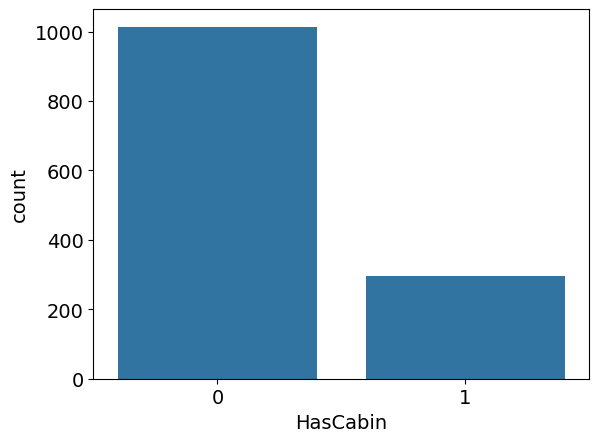

In [29]:
sns.countplot(data=df, x="HasCabin")
plt.show()

### CabinValueCounts

In [30]:
df["CabinValueCounts"] = count_values(df, "Cabin")
display(stats(df).loc[["CabinValueCounts"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
CabinValueCounts,float64,295,1014 (78%),6,2.0,126,2.071186,1.197368,1.0,1.0,2.0,2.0,6.0


### Deck

In [31]:
from titanic.features import extract_deck
df["Deck"] = extract_deck(df)
display(stats(df).loc[["Deck"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Deck,str,295,1014 (78%),8,C,94,/,/,/,/,/,/,/


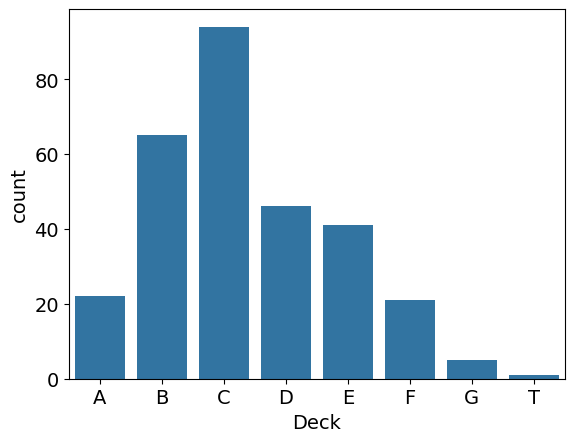

In [32]:
order = sorted(df["Deck"].dropna().unique())

sns.countplot(
    data=df,
    x="Deck",
    order=order
)

plt.show()

### CabinNumber

In [33]:
from titanic.features import extract_cabin_number
df["CabinNumber"] = extract_cabin_number(df)
display(stats(df).loc[["CabinNumber"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
CabinNumber,float64,289,1020 (78%),104,6.0,9,49.615917,34.0186,2.0,23.0,43.0,73.0,148.0


In [34]:
df[df["CabinNumber"].notna()][["CabinNumber"]].sample(10, random_state=42)

,CabinNumber
230,83.0
711,124.0
1255,50.0
215,36.0
802,96.0
52,33.0
245,78.0
763,96.0
341,23.0
871,35.0


### CabinCount

In [35]:
from titanic.features import count_cabins
df["CabinCount"] = count_cabins(df)
display(stats(df).loc[["CabinCount"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
CabinCount,int64,1309,0 (0%),5,0,1020,0.262032,0.560637,0.0,0.0,0.0,0.0,4.0


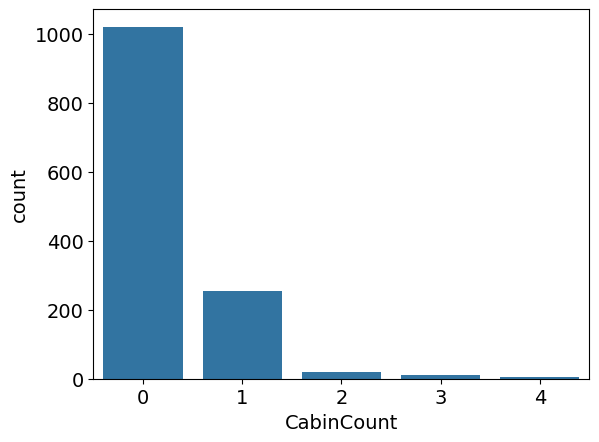

In [36]:
sns.countplot(data=df, x="CabinCount")
plt.show()

### FareValueCounts

In [37]:
df["FareValueCounts"] = count_values(df, "Fare")
display(stats(df).loc[["FareValueCounts"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
FareValueCounts,int64,1309,0 (0%),26,2,148,18.784568,20.39404,1.0,3.0,8.0,26.0,61.0


### FarePerTicketPassenger

FarePerTicketPassenger = Fare / TicketValueCounts
- Prix par passager en utilisant uniquement le numéro de ticket.


In [38]:
from titanic.features import compute_fare_per_ticket_passenger

# Fare based on exact ticket count
df["FarePerTicketPassenger"] = compute_fare_per_ticket_passenger(df)
df["FarePerTicketPassenger_log1p"] = np.log1p(df["FarePerTicketPassenger"])


display(stats(df).loc[["FarePerTicketPassenger"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
FarePerTicketPassenger,float64,1309,0 (0%),260,13.0,101,14.752503,13.551723,0.0,7.55,8.05,15.0,128.0823


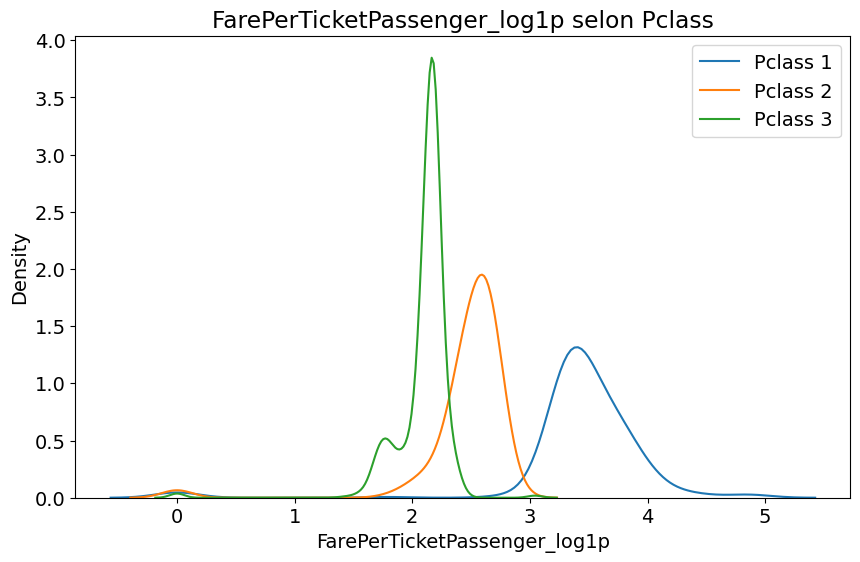

In [39]:
plt.figure(figsize=(10,6))

for pclass in sorted(df["Pclass"].unique()):
    sns.kdeplot(
        data=df[df["Pclass"] == pclass],
        x="FarePerTicketPassenger_log1p",
        label=f"Pclass {pclass}",
        fill=False
    )

plt.legend()
plt.title("FarePerTicketPassenger_log1p selon Pclass")
plt.show()

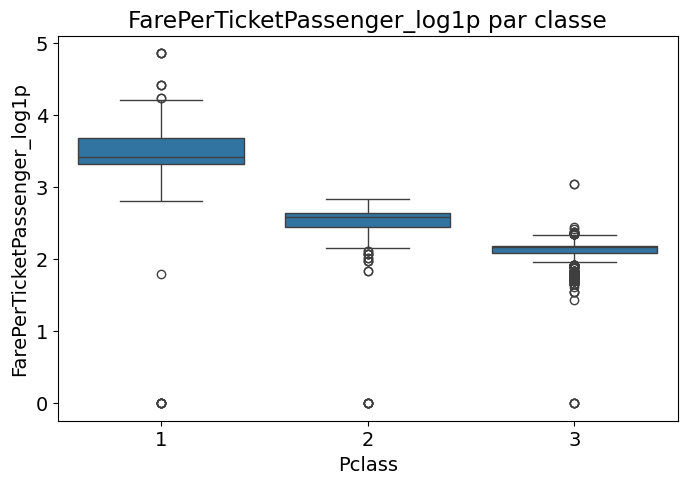

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pclass",
    y="FarePerTicketPassenger_log1p"
)

plt.title("FarePerTicketPassenger_log1p par classe")
plt.show()

### FarePerPerson

FarePerPerson = Fare / GroupSize
- Prix par personne en utilisant un groupe reconstruit heuristiquement ()

In [41]:
from titanic.features import compute_group_size, assign_group_type, compute_fare_per_person

# Group
df["GroupSize"] = compute_group_size(df)
df["GroupType"] = assign_group_type(df)

# Fare based on inferred group size
df["FarePerPerson"] = compute_fare_per_person(df)
df["FarePerPerson_log1p"] = np.log1p(df["FarePerPerson"])

display(stats(df).loc[["FarePerPerson"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
FarePerPerson,float64,1309,0 (0%),361,13.0,83,14.070078,18.536578,0.0,4.79375,7.8292,13.275,256.1646


### Age - Benchmark des méthodes d'imputation de Age

- La variable `Age` présente environ 20 % de valeurs manquantes. Comme cette variable est potentiellement importante pour la prédiction de la survie, l'imputation ne doit pas être traitée comme une simple opération mécanique.  
- Pour comparer plusieurs stratégies, nous avons utilisé uniquement les passagers dont l'âge est connu, puis masqué artificiellement 20 % de ces âges. Chaque méthode d'imputation est ensuite évaluée sur sa capacité à retrouver les âges masqués.  
- La métrique principale utilisée est la MAE, qui mesure l'erreur moyenne en années.

On commence par réaliser un benchmark de différentes méthodes d’imputation.  
On choisira simplement celle qui a les meilleurs résultats, réalisé sur des variables en mode supervisé, c’est-à-dire pour lesquelles on connaît réellement les âges.

In [42]:
from titanic.imputations_age import benchmark_age_imputations

Avant de lancer le benchmark, il faut au minimum :
```python
df["Title"]
df["FarePerTicketPassenger"]
df["FarePerTicketPassenger_log1p"]
df["FarePerPerson"]
df["FarePerPerson_log1p"]
```

In [43]:
# variables candidates

age_features = [
    "Pclass",
    "Sex",
    "Title",
    "SibSp",
    "Parch",
    "FarePerTicketPassenger_log1p",
    "Embarked"
]

categorical_features = [
    "Sex",
    "Title",
    "Embarked"
]

C’est un bon mix :

- `Title` : probablement le plus important
- `Pclass` : statut social
- `FarePerTicketPassenger_log1p` : niveau économique
- `FarePerPerson_log1p` : niveau économique
- `SibSp`, Parch : structure familiale
- `Sex` : utile, même si partiellement capturé par Title
- `Embarked` : léger signal possible

In [44]:


age_benchmark_results = benchmark_age_imputations(
    df=df,
    features=age_features,
    categorical_features=categorical_features,
    mask_frac=0.2,
    random_state=42
)

age_benchmark_results
# regarder MAE : en moyenne, l’imputation se trompe d’environ x ans.

,MAE,RMSE,R2
ExtraTreesRegressor,8.326465,11.144213,0.450861
IterativeExtraTrees,8.336508,11.138132,0.451460
RandomForest,8.482348,11.131444,0.452119
Median_by_Title_Pclass,8.678612,11.352420,0.430150
LinearRegression,9.029448,11.354630,0.429928
KNNRegressor,9.273330,12.134495,0.348931
Median_by_Title,9.582919,12.529387,0.305866
KNNImputer,10.146681,13.231380,0.225906
Median,11.515933,15.065556,-0.003584


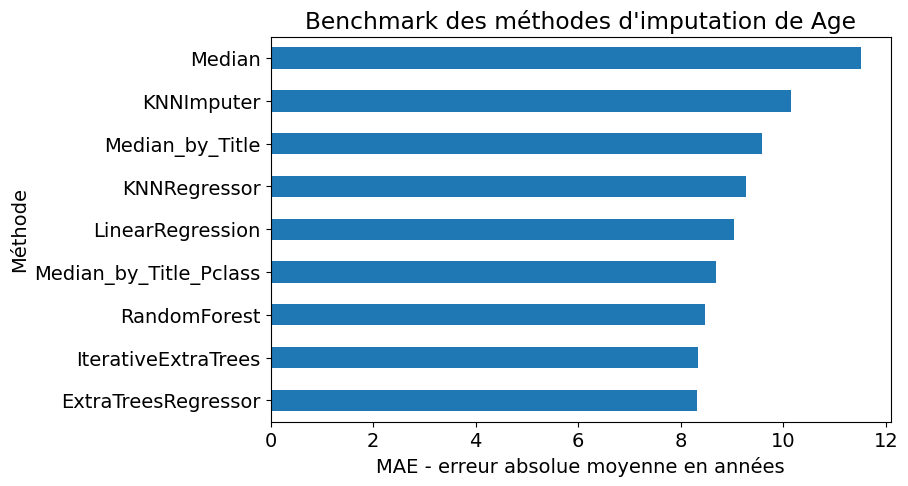

In [45]:
# visualisation simple des résultats
age_benchmark_results["MAE"].sort_values().plot(kind="barh", figsize=(8, 5))

plt.title("Benchmark des méthodes d'imputation de Age")
plt.xlabel("MAE - erreur absolue moyenne en années")
plt.ylabel("Méthode")
plt.show()

### Age - Imputation des 20% manquants

In [46]:
from titanic.imputations_age import impute_age_iterative_extra_trees

df["AgeETR"] = impute_age_iterative_extra_trees(
    df=df,
    features=age_features,
    categorical_features=categorical_features,
    age_col="Age",
    random_state=42,
    max_iter=50
)

### AgeGroup

In [47]:
from titanic.features import assign_age_group
df["AgeGroup"] = assign_age_group(df, "AgeETR")
display(stats(df).loc[["AgeGroup"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
AgeGroup,object,1309,0 (0%),7,adult,815,/,/,/,/,/,/,/


### AgeDecade

In [48]:
from titanic.features import assign_age_decade
df["AgeDecade"] = assign_age_decade(df, "AgeETR")
display(stats(df).loc[["AgeDecade"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
AgeDecade,category,1309,0 (0%),9,20-29,476,/,/,/,/,/,/,/


### IsChild

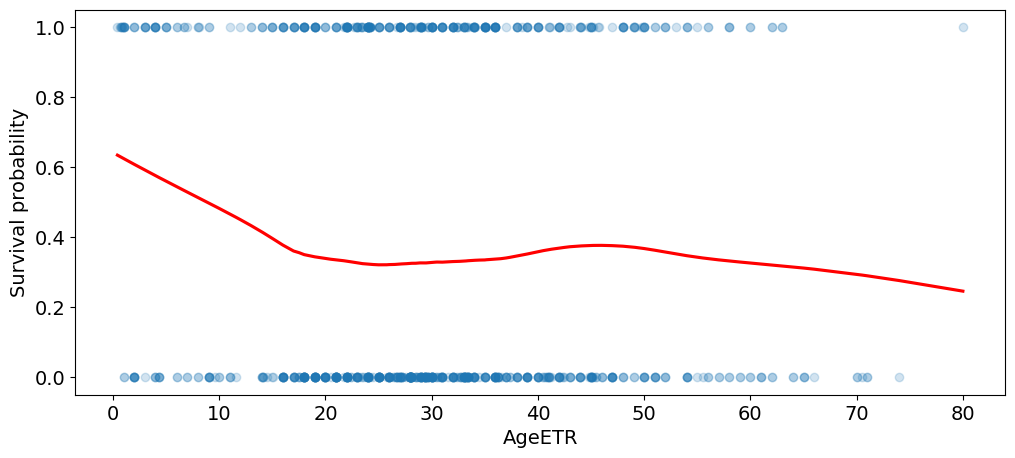

In [49]:
plt.figure(figsize=(12,5))

sns.regplot(
    data=df[df["Survived"].notna()],
    x="AgeETR",
    y="Survived",
    lowess=True,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.ylabel("Survival probability")
plt.show()

In [50]:
results = []

for threshold in range(1, 18):

    is_child = (df["AgeETR"] < threshold).astype(int)

    survival_child = df.loc[
        is_child == 1,
        "Survived"
    ].mean()

    survival_adult = df.loc[
        is_child == 0,
        "Survived"
    ].mean()

    diff = survival_child - survival_adult

    results.append({
        "threshold": threshold,
        "survival_child": survival_child,
        "survival_adult": survival_adult,
        "difference": diff
    })

results = pd.DataFrame(results)

results.sort_values(
    "difference",
    ascending=False
).head(10)

,threshold,survival_child,survival_adult,difference
0,1,1.000000,0.378959,0.621041
1,2,0.857143,0.376283,0.480860
3,4,0.666667,0.373984,0.292683
6,7,0.648148,0.366786,0.281362
5,6,0.645833,0.368921,0.276913
7,8,0.631579,0.366906,0.264672
8,9,0.629032,0.365501,0.263532
2,3,0.625000,0.377163,0.247837
4,5,0.613636,0.371901,0.241736
9,10,0.577465,0.367073,0.210392


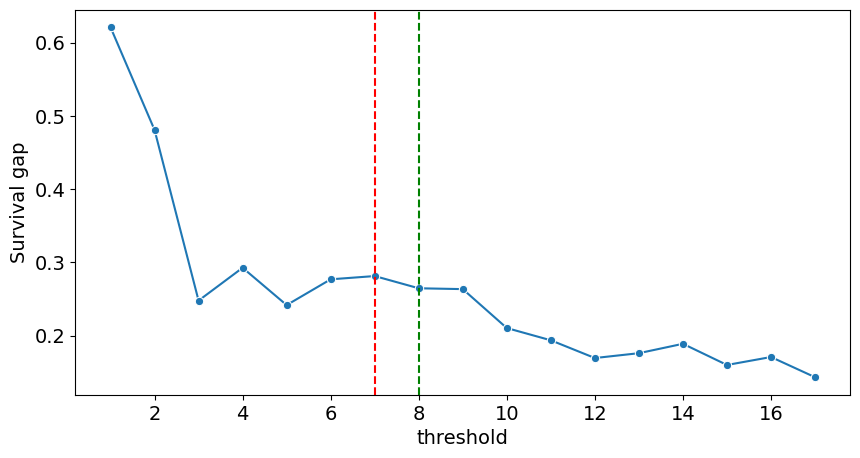

In [51]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=results,
    x="threshold",
    y="difference",
    marker="o"
)

plt.axvline(7, color="red", linestyle="--")
plt.axvline(8, color="green", linestyle="--")

plt.ylabel("Survival gap")
plt.show()

In [52]:
from sklearn.tree import DecisionTreeClassifier

X = df.loc[
    df["Survived"].notna(),
    ["AgeETR"]
]

y = df.loc[
    df["Survived"].notna(),
    "Survived"
]

tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

tree.fit(X, y)

print(tree.tree_.threshold[0])

6.850723505020142


donc on retient le seuil de 7

In [53]:
df["IsChild"] = (df["AgeETR"] < 7).astype(int)
display(stats(df).loc[["IsChild"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
IsChild,int64,1309,0 (0%),2,0,1238,0.05424,0.226577,0.0,0.0,0.0,0.0,1.0


## Dataset overview

In [54]:
print(stats(df).shape)
stats(df)

(41, 13)


,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,int64,1309,0 (0%),1309,1,1,655.0,378.020061,1.0,328.0,655.0,982.0,1309.0
Survived,float64,891,418 (32%),2,0.0,549,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,int64,1309,0 (0%),3,3,709,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
Name,str,1309,0 (0%),1307,"Connolly, Miss. Kate",2,/,/,/,/,/,/,/
Sex,str,1309,0 (0%),2,male,843,/,/,/,/,/,/,/
Age,float64,1046,263 (21%),98,24.0,47,29.881138,14.413493,0.17,21.0,28.0,39.0,80.0
SibSp,int64,1309,0 (0%),7,0,891,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
Parch,int64,1309,0 (0%),8,0,1002,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
Ticket,str,1309,0 (0%),929,CA. 2343,11,/,/,/,/,/,/,/
Fare,float64,1309,0 (0%),281,8.05,61,33.276193,51.743584,0.0,7.8958,14.4542,31.275,512.3292
